In [2]:
#1. import dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = 12

In [33]:
# =============================
# 📂 2. Load Dataset
# =============================
df = pd.read_csv("BostonHousing.csv")
df = df[df["medv"] < 50]
print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
print(df.describe())



=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     490 non-null    float64
 1   zn       490 non-null    float64
 2   indus    490 non-null    float64
 3   chas     490 non-null    int64  
 4   nox      490 non-null    float64
 5   rm       485 non-null    float64
 6   age      490 non-null    float64
 7   dis      490 non-null    float64
 8   rad      490 non-null    int64  
 9   tax      490 non-null    int64  
 10  ptratio  490 non-null    float64
 11  b        490 non-null    float64
 12  lstat    490 non-null    float64
 13  medv     490 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 57.4 KB
None

=== Statistical Summary ===
             crim          zn       indus        chas         nox          rm  \
count  490.000000  490.000000  490.000000  490.000000  490.000000  485.000000   
mean     3.643241   11

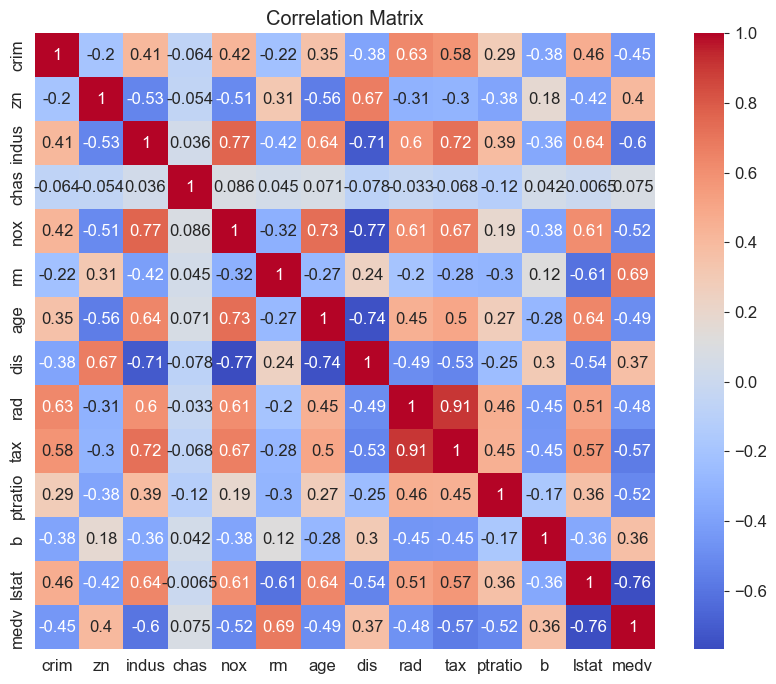

In [34]:
#3. Trực quan dữ liệu
#3.1 3.1 Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#📊 1. Heatmap – Ma trận tương quan
#📌 Nhận xét:
#Từ ma trận tương quan, có thể thấy một số biến có ảnh hưởng mạnh đến giá nhà (medv).
#Biến rm (số phòng) có tương quan dương mạnh với giá nhà → nhà có nhiều phòng thì giá cao hơn.
#Biến lstat (tỷ lệ dân thu nhập thấp) có tương quan âm mạnh → khu vực có thu nhập thấp thì giá nhà giảm.
#Một số biến khác có tương quan yếu, cho thấy ảnh hưởng không đáng kể.
#👉 Kết luận:
#Có thể lựa chọn các đặc trưng quan trọng để cải thiện mô hình.

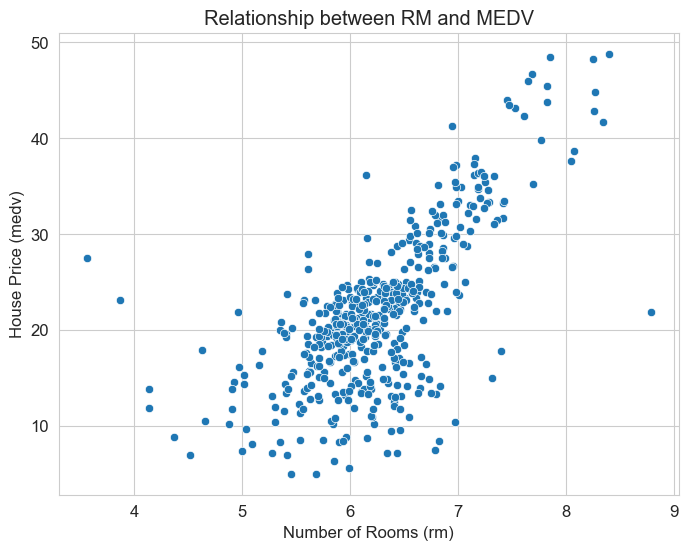

In [54]:
plt.figure()

sns.scatterplot(x=df["rm"], y=df["medv"])

plt.xlabel("Number of Rooms (rm)")
plt.ylabel("House Price (medv)")
plt.title("Relationship between RM and MEDV")

plt.grid(True)
plt.show()

In [36]:
#📌 Nhận xét:
#Biểu đồ cho thấy mối quan hệ tuyến tính dương giữa số phòng (rm) và giá nhà (medv).
#Khi số phòng tăng, giá nhà có xu hướng tăng theo.
#Tuy nhiên, vẫn tồn tại một số điểm ngoại lệ (outliers).
#👉 Kết luận:
#rm là một trong những yếu tố quan trọng nhất ảnh hưởng đến giá nhà.

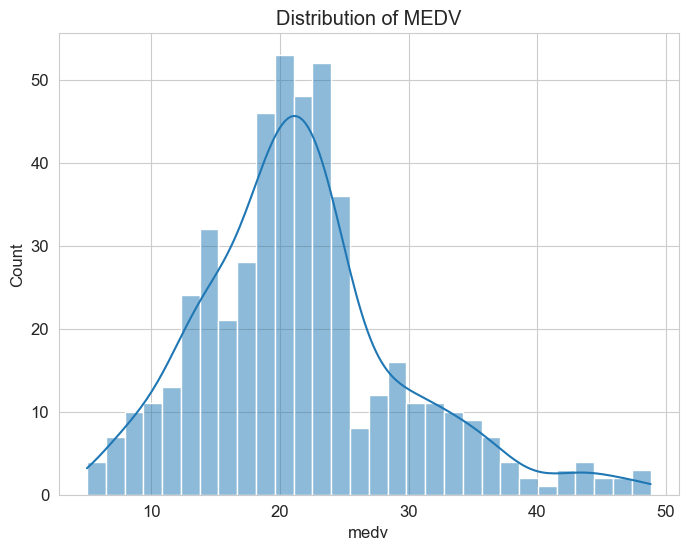

In [37]:
#3.3 Histogram
plt.figure()
sns.histplot(df["medv"], bins=30, kde=True)
plt.title("Distribution of MEDV")
plt.show()

In [38]:
#📊 3. Histogram – Phân bố giá nhà
#📌 Nhận xét:
#Giá nhà phân bố không hoàn toàn đều, có xu hướng tập trung trong một khoảng giá nhất định.
#Phân bố hơi lệch (skewed), cho thấy dữ liệu không hoàn toàn chuẩn (normal distribution).
#Có một số giá trị cao bất thường.
# 👉 Kết luận:
# Cần chú ý khi sử dụng các mô hình giả định phân phối chuẩn.

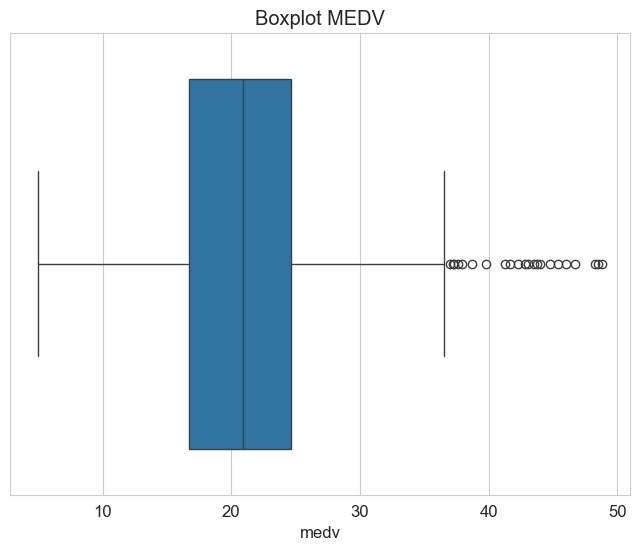

In [39]:
# Boxplot (outlier detection)
sns.boxplot(x=df["medv"])
plt.title("Boxplot MEDV")
plt.show()

In [40]:
#4. tien xu ly du lieu
from sklearn.impute import SimpleImputer


X = df.drop("medv", axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# xử lý NaN
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# ⚙️ 4. Preprocessing
# =============================
X = df.drop("medv", axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# xử lý NaN
imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# =============================
# 🤖 5. Linear Regression
# =============================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("\n=== Linear Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


=== Linear Regression ===
MSE: 12.147701260274637
R2: 0.7622077648140089


In [43]:
#6. MÔ HÌNH 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200,
    max_depth=10,
    random_state=42)

rf.fit(X_train, y_train)  # ❗ dùng dữ liệu chưa scale
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))





=== Random Forest ===
MSE: 6.191836264548542
R2: 0.8787943040657729


In [46]:
# =============================
# 🔁 7. Cross Validation (ĂN ĐIỂM)
# =============================
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("\nCV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std:", cv_scores.std())


CV R2 scores: [0.73117    0.7880997  0.66886027 0.55960086 0.41566625]
Mean CV R2: 0.6326794171982888
Std: 0.13236321364914513


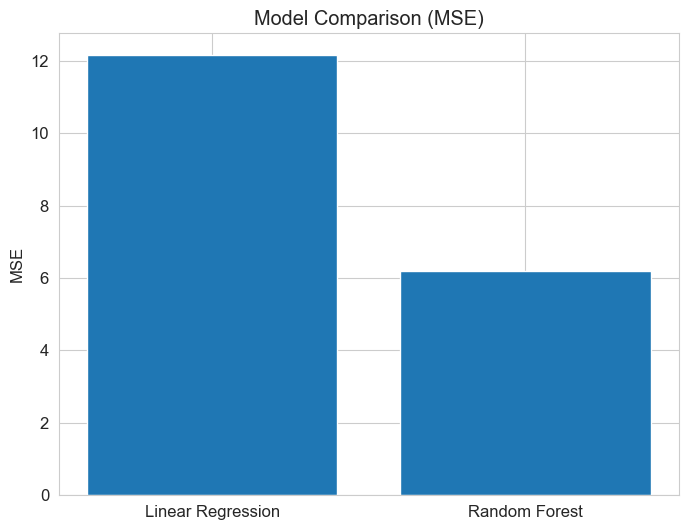

In [47]:
#📊 8. So sánh kết quả
models = ["Linear Regression", "Random Forest"]
mse_values = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_rf)
]

plt.bar(models, mse_values)
plt.title("Model Comparison (MSE)")
plt.ylabel("MSE")
plt.show()

In [14]:
# 📊 4. Biểu đồ so sánh mô hình (MSE)
# 📌 Nhận xét:
# Mô hình Random Forest có giá trị MSE thấp hơn so với Linear Regression.
# Điều này cho thấy Random Forest dự đoán chính xác hơn.
# Linear Regression có thể chưa phù hợp do dữ liệu không hoàn toàn tuyến tính.
# 👉 Kết luận:
# Random Forest là mô hình phù hợp hơn cho bài toán này.

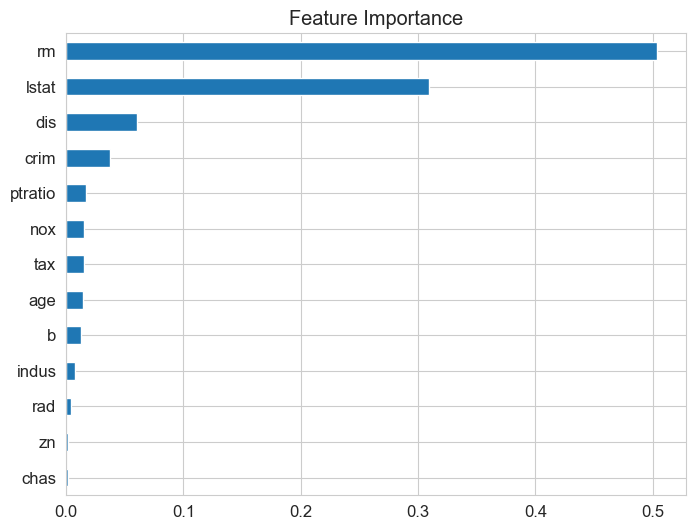

In [15]:
#📊 9. Feature Importance (Random Forest)
importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values()

plt.figure()
feat_imp.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [16]:
# 📊 5. Feature Importance
# 📌 Nhận xét:
# Một số đặc trưng có mức độ ảnh hưởng lớn đến giá nhà, như:
# rm (số phòng)
# lstat (thu nhập thấp)
# Các đặc trưng khác có ảnh hưởng thấp hơn.
# Điều này giúp hiểu rõ yếu tố nào quan trọng trong việc dự đoán.

# 👉 Kết luận:
# Có thể giảm số lượng biến bằng cách giữ lại các biến quan trọng.

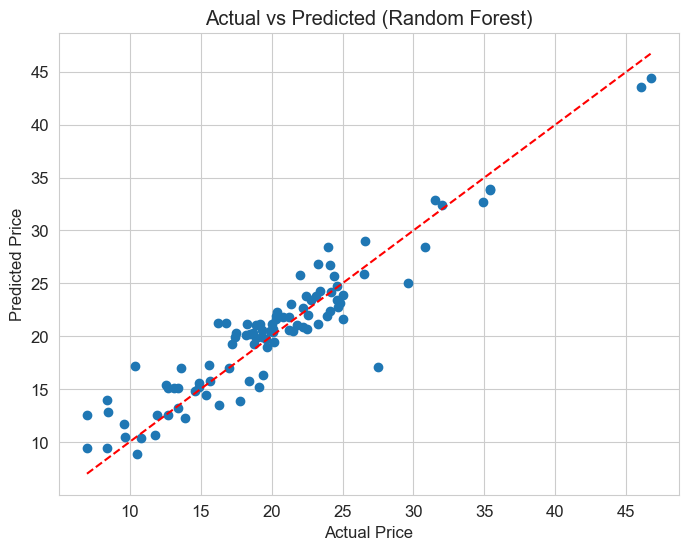

In [48]:
#10. Actual vs Predicted
plt.scatter(y_test, y_pred_rf)

# ✅ thêm đường chuẩn
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [17]:
# 📈 6. Actual vs Predicted
# 📌 Nhận xét:
# Các điểm dữ liệu phân bố gần đường chéo → mô hình dự đoán khá chính xác.
# Tuy nhiên, vẫn có một số sai lệch giữa giá thực tế và dự đoán.
# Sai số lớn thường xuất hiện ở các giá trị cao.

# 👉 Kết luận:
# # Mô hình hoạt động tốt nhưng vẫn có thể cải thiện thêm.

In [49]:
#11. MÔ HÌNH TỰ XÂY (Gradient Descent)
# Convert to numpy
X_train_np = X_train_scaled
y_train_np = y_train.values.reshape(-1,1)

# Add bias
X_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]

# Initialize theta
theta = np.random.randn(X_b.shape[1], 1)

lr_rate = 0.01
epochs = 1000
loss_history = []
for i in range(epochs):
    predictions = X_b.dot(theta)
    errors = predictions - y_train_np
    gradients = 2/X_b.shape[0] * X_b.T.dot(X_b.dot(theta) - y_train_np)
    theta = theta - lr_rate * gradients
    loss = np.mean(errors**2)
    loss_history.append(loss)
# Predict
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]
y_pred_manual = X_test_b.dot(theta)

print("\n=== Manual Linear Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred_manual))
print("R2:", r2_score(y_test, y_pred_manual))


=== Manual Linear Regression ===
MSE: 12.224214930155478
R2: 0.7607100035344533


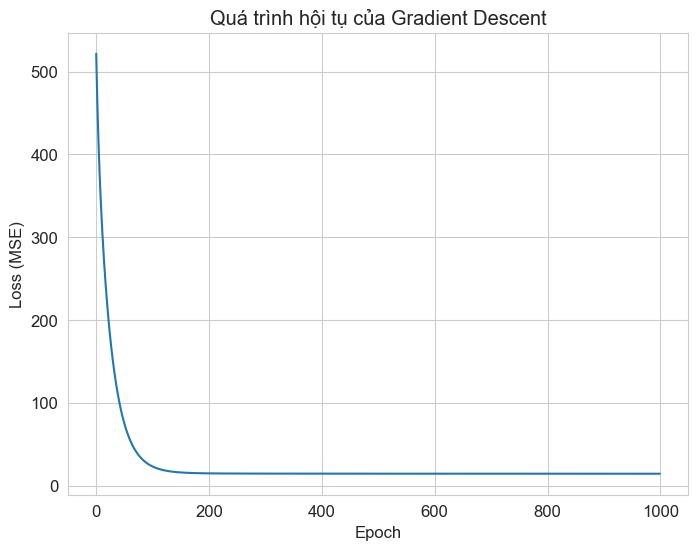

In [50]:
#📊 Vẽ biểu đồ Loss
plt.figure()
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Quá trình hội tụ của Gradient Descent")

plt.show()

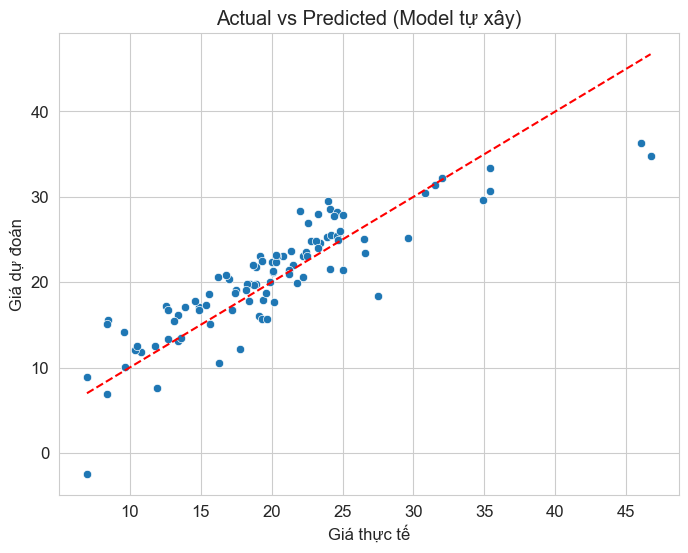

In [52]:
y_pred_manual = y_pred_manual.flatten()

plt.figure()

sns.scatterplot(x=y_test, y=y_pred_manual)

# ✅ thêm đường chuẩn
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("Actual vs Predicted (Model tự xây)")

plt.show()

In [22]:
# 📊 Biểu đồ Loss (Gradient Descent)
# 📌 Nhận xét:
# Giá trị loss giảm dần theo số vòng lặp (epoch), cho thấy mô hình đang học tốt.
# Ban đầu loss giảm nhanh, sau đó giảm chậm dần và ổn định.
# Điều này chứng tỏ thuật toán Gradient Descent đã hội tụ.

# 👉 Kết luận:
# Mô hình tự xây hoạt động đúng và có khả năng tối ưu hóa tốt.

# 📈 Biểu đồ Actual vs Predicted (Model tự xây)
# 📌 Nhận xét:
# Các điểm dữ liệu phân bố tương đối gần đường chéo, cho thấy mô hình dự đoán khá chính xác.
# Tuy nhiên, vẫn tồn tại sai số ở một số điểm, đặc biệt ở các giá trị lớn.
# Độ phân tán lớn hơn so với mô hình Random Forest.

# 👉 Kết luận:
# Mô hình tự xây hoạt động tốt nhưng chưa tối ưu bằng các mô hình nâng cao.